<style>
.cours-hero {padding: 1.15rem 1.3rem; border-left: 6px solid #1f4e79; background: #f3f7fb; margin: .5rem 0 1rem 0;}
.objectif {padding: .8rem 1rem; border-left: 5px solid #2f855a; background: #f2fbf6; margin: .7rem 0;}
.attention {padding: .8rem 1rem; border-left: 5px solid #b7791f; background: #fffaf0; margin: .7rem 0;}
.oral {padding: .8rem 1rem; border-left: 5px solid #6b46c1; background: #faf5ff; margin: .7rem 0;}
.exercice {padding: .8rem 1rem; border-left: 5px solid #c53030; background: #fff5f5; margin: .7rem 0;}
.petit {font-size: .92em; color: #4a5568;}
</style>

<div class="cours-hero">

# Carnet d’apprentissage — Inférence causale

**Projet étudié :** effet d’une session durant le weekend, plutôt qu’en semaine, sur la probabilité de transaction  
**Finalité :** comprendre le projet en profondeur, l’expliquer clairement et le défendre lorsque les questions sortent du script

</div>

**Version du carnet :** 0.1  
**Bloc actuellement ouvert :** modules 0 et 1  
**Prochain bloc prévu :** question contrefactuelle, intervention et estimand

> Ce notebook est un espace d’apprentissage. Il ne modifie pas le projet déjà soumis.


## Comment travailler avec ce carnet

Ce cours n’est pas destiné à être seulement lu. Pour chaque notion, nous suivrons le même cycle :

1. **Comprendre sans jargon.** Construire une image mentale correcte.
2. **Relier au projet.** Identifier la variable, le chiffre, la figure ou le choix méthodologique concerné.
3. **Récupérer de mémoire.** Fermer les notes et répondre avec ses propres mots.
4. **Défendre oralement.** Répondre en 20 secondes, puis en 60 secondes si le jury insiste.
5. **Corriger précisément.** Distinguer une imprécision de vocabulaire d’une véritable erreur de raisonnement.

### Structure recommandée pour une réponse de soutenance

<div class="oral">

**Définition simple → Application au projet → Chiffre ou élément concret → Limite**

Cette structure sera abrégée **D–A–C–L** dans le carnet.

</div>

### Échelle personnelle de maîtrise

| Niveau | Ce que je suis capable de faire |
|---:|---|
| 0 | Je ne reconnais pas encore la notion. |
| 1 | Je la reconnais lorsqu’on me l’explique. |
| 2 | Je peux la définir avec mes mots. |
| 3 | Je peux l’appliquer correctement au projet. |
| 4 | Je peux la défendre face à une objection imprévue. |

**Règle importante :** une notion n’est pas maîtrisée parce qu’une explication « paraît claire ». Elle est maîtrisée lorsqu’on peut la reconstruire sans regarder.

### Rappel Jupyter pour débuter

- Cliquer dans une cellule puis utiliser **Maj + Entrée** pour l’exécuter et passer à la suivante.
- Le symbole `[*]` signifie qu’une cellule est en cours d’exécution ; un nombre comme `[3]` indique qu’elle est terminée.
- Exécuter les cellules dans l’ordre. Si les résultats deviennent incohérents : **Kernel → Restart Kernel and Run All Cells**.
- Les cellules intitulées « ✍️ Ma réponse » sont des cellules Markdown : double-cliquer pour écrire, puis **Maj + Entrée** pour afficher proprement le texte.


## Carte complète du parcours

| Module | Question centrale | État |
|---:|---|---|
| 0 | Quelle histoire générale raconte le projet ? | **À travailler maintenant** |
| 1 | Comment lire correctement les taux, différences et intervalles ? | **À travailler maintenant** |
| 2 | Quelle quantité causale voulons-nous réellement estimer ? | À venir |
| 3 | Comment distinguer confondeur, médiateur, collider et variable post-exposition ? | À venir |
| 4 | Que représentent le DAG, la porte arrière et les hypothèses d’identification ? | À venir |
| 5 | Pourquoi restreindre à `SpecialDay=0` et comment comprendre la positivité ? | À venir |
| 6 | Comment fonctionnent la standardisation, l’IPW, l’AIPW et le cross-fitting ? | À venir |
| 7 | Comment interpréter score de propension, poids, ESS et SMD ? | À venir |
| 8 | Que font FCI et le PAG, et que ne prouvent-ils pas ? | À venir |
| 9 | Comment défendre résultats, robustesse, E-value, limites et reproductibilité ? | À venir |
| 10 | Comment présenter chaque diapositive et répondre au contre-interrogatoire ? | **Étape finale** |

<div class="attention">

Les futurs modules ne sont volontairement pas développés tout de suite. Tes réponses aux exercices détermineront le niveau de détail, les exemples supplémentaires et les retours nécessaires.

</div>


## Tableau de progression

À mettre à jour après chaque séance.

| Date | Module | Niveau avant | Niveau après | Point encore fragile | Prochaine action |
|---|---:|---:|---:|---|---|
| _À remplir_ | 0–1 | 0 | _/4_ | _À remplir_ | Répondre aux exercices sans notes |

### Nombres d’ancrage à connaître à la fin du parcours

`12 330` · `11 079` · `8 371 / 2 708` · `18,06 / 16,03` · `+2,03` · `+1,51 [−0,18 ; 3,19]` · `0,268 → 0,040` · `E-value 1,41`

Ils seront appris progressivement avec leur **signification**, jamais comme une suite de nombres isolés.


# Module 0 — Comprendre l’histoire générale du projet

<div class="objectif">

**Objectif de maîtrise :** raconter en une minute ce que le projet cherche à faire, sans formules et sans le confondre avec un projet de prédiction.

**Prérequis :** aucun.

</div>


## Diagnostic initial — répondre avant le cours

Pour chaque affirmation, écrire **Vrai**, **Faux** ou **Je ne sais pas**, puis une justification d’une phrase. Le but n’est pas d’obtenir une bonne note : il s’agit de conserver une trace de ton intuition de départ.

1. Une ligne de la base représente nécessairement un client unique.
2. `Revenue` mesure le montant d’argent gagné pendant la session.
3. Comme le taux de transaction est plus élevé le weekend, le weekend cause davantage d’achats.
4. Une hausse de 1,5 point de pourcentage signifie toujours une hausse relative de 1,5 %.
5. Si un intervalle de confiance contient zéro, cela prouve que l’effet est exactement nul.
6. Pour supprimer les biais, il suffit d’ajuster sur toutes les variables qui prédisent bien `Revenue`.
7. L’AIPW élimine aussi la confusion causée par des variables qui ne figurent pas dans les données.
8. Si FCI ne place pas d’arête entre `Weekend` et `Revenue`, cela prouve l’absence d’effet causal.


### ✍️ Mes réponses au diagnostic

> Double-cliquer dans cette cellule pour la modifier. Ne pas effacer tes premières réponses après correction : ajoute plutôt une seconde formulation afin de voir ta progression.

| Nº | Vrai / Faux / ? | Ma justification initiale | Correction ultérieure |
|---:|---|---|---|
| 1 | _À remplir_ | _À remplir_ | |
| 2 | _À remplir_ | _À remplir_ | |
| 3 | _À remplir_ | _À remplir_ | |
| 4 | _À remplir_ | _À remplir_ | |
| 5 | _À remplir_ | _À remplir_ | |
| 6 | _À remplir_ | _À remplir_ | |
| 7 | _À remplir_ | _À remplir_ | |
| 8 | _À remplir_ | _À remplir_ | |


## 0.1 Prédire n’est pas expliquer causalement

Deux questions peuvent utiliser les mêmes données tout en étant profondément différentes.

**Question prédictive**  
« À partir de ce que l’on observe pendant la navigation, quelles sessions termineront par une transaction ? »

**Question causale**  
« Pour des sessions comparables, que changerait le fait qu’elles aient lieu le weekend plutôt qu’en semaine ? »

Un excellent prédicteur n’est pas automatiquement une bonne variable d’ajustement causal. Par exemple, `PageValues` peut fortement prédire `Revenue`, mais elle est construite pendant la navigation et son ordre par rapport à la transaction courante est incertain. L’ajuster sans raisonnement temporel peut déformer la question causale.

<div class="attention">

**Phrase à éviter :** « Le projet cherche à prédire si un client va acheter. »  
**Formulation correcte :** « Le projet cherche à estimer un contraste moyen de probabilité de transaction entre weekend et semaine, sous des hypothèses causales. »

</div>


## 0.2 Le fil narratif en six étapes

1. Nous observons une différence de taux de transaction entre weekend et semaine.
2. Les deux groupes n’ont pas été constitués par randomisation.
3. Nous formulons une comparaison hypothétique suffisamment précise.
4. Nous utilisons les connaissances du domaine et un DAG pour choisir les variables d’ajustement.
5. Nous estimons un contraste ajusté et examinons les diagnostics.
6. Nous concluons prudemment, car l’incertitude et les variables non observées demeurent.

Ce fil sera enrichi dans les modules suivants. Pour le moment, il faut surtout comprendre pourquoi l’étape 2 empêche de passer directement de l’observation à une conclusion causale.


## 0.3 Ouvrir les données sans se perdre dans le code

Les prochaines cellules servent à relier le cours au fichier réellement soumis. Il n’est pas encore nécessaire de comprendre chaque instruction Python.

**À observer lors de l’exécution :**

- le chemin du fichier utilisé ;
- ses dimensions ;
- l’absence d’identifiant de client ;
- la nature booléenne de `Weekend` et `Revenue`.


In [1]:
from pathlib import Path
import base64
import hashlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

NOM_DONNEES = Path("02_data/raw/online_shoppers_intention.csv")

def trouver_racine() -> Path:
    '''Trouver la racine du projet même si Jupyter a été lancé depuis un sous-dossier.'''
    candidats = [Path.cwd(), *Path.cwd().parents]
    for candidat in candidats:
        if (candidat / NOM_DONNEES).is_file():
            return candidat
    raise FileNotFoundError(
        "Impossible de trouver 02_data/raw/online_shoppers_intention.csv. "
        "Lancer Jupyter depuis le dossier rendu_final ou l'un de ses sous-dossiers."
    )

RACINE = trouver_racine()
CHEMIN_DONNEES = RACINE / NOM_DONNEES
CHEMIN_ESTIMATIONS = RACINE / "04_outputs/tableaux/02_estimations_principales.csv"

print(f"Racine détectée : {RACINE}")
print(f"Données utilisées : {CHEMIN_DONNEES}")


Racine détectée : C:\Users\Tazi\Desktop\School\Projet\projet_ml_causalite_agent\04_outputs\rendu_final
Données utilisées : C:\Users\Tazi\Desktop\School\Projet\projet_ml_causalite_agent\04_outputs\rendu_final\02_data\raw\online_shoppers_intention.csv


In [2]:
EMPREINTE_ATTENDUE = "b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9"
empreinte_observee = hashlib.sha256(CHEMIN_DONNEES.read_bytes()).hexdigest()
assert empreinte_observee == EMPREINTE_ATTENDUE, "Le fichier CSV n'est pas la copie validée."

donnees = pd.read_csv(CHEMIN_DONNEES)
assert donnees.shape == (12_330, 18)

print(f"Empreinte vérifiée : {empreinte_observee[:16]}…")
print(f"Dimensions : {donnees.shape[0]:,} sessions × {donnees.shape[1]} variables".replace(",", " "))
print(f"Colonnes : {', '.join(donnees.columns)}")


Empreinte vérifiée : b3055ee355f59134…
Dimensions : 12 330 sessions × 18 variables
Colonnes : Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues, SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType, VisitorType, Weekend, Revenue


In [3]:
apercu_variables = pd.DataFrame(
    {
        "Variable": ["Weekend", "Revenue", "SpecialDay"],
        "Type Python": [str(donnees[c].dtype) for c in ["Weekend", "Revenue", "SpecialDay"]],
        "Interprétation": [
            "Exposition calendaire : weekend ou semaine",
            "Résultat binaire : transaction ou non",
            "Proximité d'un jour commercial spécial",
        ],
    }
)
display(apercu_variables)

colonnes_identifiantes = [
    c for c in donnees.columns
    if any(mot in c.casefold() for mot in ("client", "customer", "user", "session_id", "id_session"))
]
print("Colonnes pouvant identifier un client ou une session :", colonnes_identifiantes or "aucune")


,Variable,Type Python,Interprétation
0,Weekend,bool,Exposition calendaire : weekend ou semaine
1,Revenue,bool,Résultat binaire : transaction ou non
2,SpecialDay,float64,Proximité d'un jour commercial spécial


Colonnes pouvant identifier un client ou une session : aucune


### Ce que ces cellules permettent déjà d’affirmer

- Une ligne correspond à une **session observée**.
- Rien dans le fichier ne permet d’établir que deux lignes proviennent ou non de la même personne.
- `Weekend` est l’exposition calendaire étudiée.
- `Revenue` indique si la session se termine par une transaction ; ce n’est pas un montant d’argent.
- Le titre original du jeu de données parle d’« intention d’achat », mais notre résultat analysé est bien une transaction binaire observée.

<div class="attention">

**Point à retenir pour la présentation finale :** une diapositive simplifie actuellement la situation en disant « une session = un utilisateur ». Les données ne permettent pas cette équivalence. À l’oral, il faudra préciser : « une ligne représente une session ; plusieurs sessions pourraient appartenir au même visiteur, car aucun identifiant individuel n’est fourni ». Nous reprendrons cette correction lors du module 10.

</div>


## Exercice 0A — Reconstruire l’histoire sans notes

<div class="exercice">

Les six étapes suivantes ont été mélangées. Remets-les dans un ordre logique, puis raconte le projet à voix haute en **60 secondes maximum**.

- A. Estimer un contraste ajusté et vérifier les diagnostics.
- B. Constater que les groupes ne sont pas randomisés.
- C. Conclure prudemment à cause de l’incertitude et des causes absentes.
- D. Observer une différence de taux.
- E. Définir une comparaison hypothétique.
- F. Choisir les variables d’ajustement à partir d’un raisonnement causal.

Ne cherche pas encore à utiliser les mots *estimand*, *positivité* ou *AIPW*. Une histoire simple et correcte vaut mieux qu’un vocabulaire technique mal maîtrisé.

</div>


### ✍️ Ma réponse à l’exercice 0A

**Ordre proposé :** _À remplir_  

**Mon explication écrite avant de la dire à voix haute :**

_À remplir en cinq ou six phrases._

**Durée de ma réponse orale :** _À remplir_  
**Endroit où j’ai hésité :** _À remplir_


## Point de passage du module 0

Avant de considérer ce module comme acquis, je dois pouvoir :

- [ ] expliquer pourquoi le projet n’est pas principalement un projet de prédiction ;
- [ ] dire qu’une ligne représente une session et non nécessairement un client ;
- [ ] identifier `Weekend` et `Revenue` sans les confondre ;
- [ ] raconter les six étapes générales en moins de 60 secondes ;
- [ ] terminer ma réponse par une limite au lieu de suraffirmer la causalité.

**Niveau actuel estimé :** _/4_


# Module 1 — Proportions, points de pourcentage, association et incertitude

<div class="objectif">

**Objectif de maîtrise :** interpréter correctement les chiffres essentiels du projet et expliquer pourquoi une différence observée n’est pas automatiquement un effet causal.

**Prérequis :** savoir diviser deux nombres et calculer une différence.

</div>


## 1.1 Pourquoi la moyenne de `Revenue` est un taux de transaction

`Revenue` ne peut prendre que deux valeurs :

\[
Revenue_i =
\begin{cases}
1 & \text{si la session } i \text{ se termine par une transaction},\\
0 & \text{sinon.}
\end{cases}
\]

La somme de cette variable compte les transactions. Sa moyenne est donc :

\[
\bar{Y}=\frac{\text{nombre de transactions}}{\text{nombre de sessions}},
\]

c’est-à-dire une **proportion** ou un **risque observé**.


In [4]:
population_principale = donnees.loc[donnees["SpecialDay"].eq(0)].copy()

resume_observe = (
    population_principale
    .groupby("Weekend", observed=True)["Revenue"]
    .agg(Sessions="size", Transactions="sum", Taux="mean")
    .rename(index={False: "Semaine", True: "Weekend"})
)
resume_observe["Taux (%)"] = 100 * resume_observe["Taux"]
resume_observe = resume_observe[["Sessions", "Transactions", "Taux (%)"]]

display(
    resume_observe.style.format(
        {"Sessions": "{:,.0f}", "Transactions": "{:,.0f}", "Taux (%)": "{:.2f} %"}
    )
)
print(f"Taille de la population principale : {len(population_principale):,}".replace(",", " "))


,Sessions,Transactions,Taux (%)
Weekend,,,
Semaine,"8,371","1,342",16.03 %
Weekend,"2,708",489,18.06 %


Taille de la population principale : 11 079


Les calculs essentiels sont :

\[
\frac{489}{2708}=18{,}06\% \quad \text{(weekend)}
\]

\[
\frac{1342}{8371}=16{,}03\% \quad \text{(semaine)}
\]

Il s’agit de deux **taux observés** dans deux groupes différents. À ce stade, nous n’avons construit aucun contrefactuel et effectué aucun ajustement causal.


### Trois paires de taux à ne jamais mélanger

| Niveau d’analyse | Semaine | Weekend | Signification |
|---|---:|---:|---|
| Échantillon complet | 14,89 % | 17,40 % | Description des 12 330 sessions |
| Population `SpecialDay=0` | 16,03 % | 18,06 % | Description brute des 11 079 sessions principales |
| Moyennes potentielles AIPW | 16,16 % | 17,67 % | Résultats ajustés sous les hypothèses de l’analyse |

Les deux premières lignes sont des moyennes réellement observées dans des populations différentes. La troisième provient d’un estimateur causal et sera expliquée beaucoup plus tard. Lors d’une question orale, toujours annoncer **de quelle population et de quel type de moyenne il s’agit**.


## 1.2 Point de pourcentage et variation relative

Supposons qu’un taux passe de 16 % à 18 %.

- La différence absolue est de **2 points de pourcentage**.
- La variation relative est \((18-16)/16=12{,}5\%\).

Ce sont deux manières différentes de décrire le même écart. Il faut toujours annoncer l’échelle utilisée.

Dans le projet, la différence brute vaut environ :

\[
18{,}06\%-16{,}03\%=2{,}03\text{ points de pourcentage}.
\]

<div class="attention">

**Erreur fréquente :** « le weekend augmente les achats de 2,03 % ».  
Cette phrase mélange l’échelle, suppose déjà la causalité et ne précise pas la population.

</div>


In [5]:
risque_semaine = population_principale.loc[~population_principale["Weekend"], "Revenue"].mean()
risque_weekend = population_principale.loc[population_principale["Weekend"], "Revenue"].mean()

difference_points = 100 * (risque_weekend - risque_semaine)
variation_relative = 100 * (risque_weekend / risque_semaine - 1)
difference_pour_1000 = 1000 * (risque_weekend - risque_semaine)

print(f"Taux semaine : {100 * risque_semaine:.3f} %")
print(f"Taux weekend : {100 * risque_weekend:.3f} %")
print(f"Différence absolue : {difference_points:.3f} points de pourcentage")
print(f"Variation relative brute : {variation_relative:.2f} %")
print(f"Écart descriptif pour 1 000 sessions : {difference_pour_1000:.1f} transactions")


Taux semaine : 16.032 %
Taux weekend : 18.058 %
Différence absolue : 2.026 points de pourcentage
Variation relative brute : 12.64 %
Écart descriptif pour 1 000 sessions : 20.3 transactions


## 1.3 Une différence observée peut provenir de la composition des groupes

Imaginons un exemple fictif dans lequel une promotion augmente le taux de transaction, mais le weekend n’a **aucun effet à niveau de promotion identique** :

- sans promotion, le taux est toujours de 10 % ;
- avec promotion, le taux est toujours de 30 % ;
- les promotions sont simplement plus fréquentes le weekend.

La cellule suivante montre que le taux global du weekend peut alors être supérieur même si les taux sont identiques à l’intérieur de chaque niveau de promotion.


In [6]:
exemple_promotion = pd.DataFrame(
    [
        ["Semaine", "Sans promotion", 800, 80],
        ["Semaine", "Avec promotion", 200, 60],
        ["Weekend", "Sans promotion", 400, 40],
        ["Weekend", "Avec promotion", 600, 180],
    ],
    columns=["Moment", "Promotion", "Sessions", "Transactions"],
)
exemple_promotion["Taux (%)"] = 100 * exemple_promotion["Transactions"] / exemple_promotion["Sessions"]

taux_globaux = (
    exemple_promotion.groupby("Moment")[["Sessions", "Transactions"]]
    .sum()
    .assign(**{"Taux global (%)": lambda d: 100 * d["Transactions"] / d["Sessions"]})
)

display(exemple_promotion)
display(taux_globaux)
print("Dans chaque niveau de promotion : mêmes taux en semaine et le weekend.")
print("Au total : 14 % en semaine contre 22 % le weekend, soit +8 points.")


,Moment,Promotion,Sessions,Transactions,Taux (%)
0,Semaine,Sans promotion,800,80,10.000
1,Semaine,Avec promotion,200,60,30.000
2,Weekend,Sans promotion,400,40,10.000
3,Weekend,Avec promotion,600,180,30.000


,Sessions,Transactions,Taux global (%)
Moment,,,
Semaine,1000,140,14.000
Weekend,1000,220,22.000


Dans chaque niveau de promotion : mêmes taux en semaine et le weekend.
Au total : 14 % en semaine contre 22 % le weekend, soit +8 points.


### Le raisonnement important

Dans cet exemple, la promotion est une **cause commune** du moment observé et de la transaction : elle modifie la composition des groupes et le résultat. La différence globale ne représente donc pas un effet du weekend.

Dans le vrai projet, les prix, promotions, campagnes, produits, heures de visite et intentions préalables ne sont pas mesurés. Nous ne savons pas s’ils expliquent une partie ou la totalité de l’écart observé.

> **Association :** les sessions de weekend ont un taux observé plus élevé.  
> **Causalité :** le déplacement hypothétique d’une session vers le weekend modifierait son résultat.

La première phrase compare des groupes réellement observés. La seconde compare deux situations hypothétiques et exige des hypothèses supplémentaires.


## 1.4 Comprendre un intervalle de confiance sans le surinterpréter

Une estimation varie parce que nous n’observons qu’un échantillon fini. Un intervalle de confiance quantifie cette **incertitude d’échantillonnage**, selon une méthode donnée.

Une manière prudente de l’expliquer est :

> « L’intervalle regroupe les valeurs raisonnablement compatibles avec les données et la procédure d’estimation. »

Dans l’interprétation fréquentiste stricte, le niveau de 95 % qualifie la **procédure** : si l’on répétait indéfiniment l’étude et la construction de l’intervalle, environ 95 % des intervalles ainsi obtenus couvriraient la vraie quantité ciblée.

**Il ne faut pas dire :** « Il y a 95 % de probabilité que le véritable effet soit dans cet intervalle. » Une fois l’intervalle calculé, ses bornes sont fixes.

### Deux résultats à ne pas confondre

- Différence **brute** : `+2,026 [0,378 ; 3,674]` points.
- Estimation **AIPW principale** : `+1,506 [−0,176 ; 3,188]` points.

L’intervalle brut exclut zéro, mais cela ne transforme pas l’association brute en effet causal : un biais de confusion n’est pas une incertitude d’échantillonnage. L’intervalle AIPW contient zéro ; il ne prouve pas que l’effet est nul, mais il ne permet pas d’écarter l’absence d’effet moyen.


,Méthode,Estimation (points),IC 95 % bas,IC 95 % haut
0,Brute,2.026,0.378,3.674
1,Standardisation,1.384,-0.317,2.984
2,IPW,1.444,-0.256,3.143
3,AIPW,1.506,-0.176,3.188



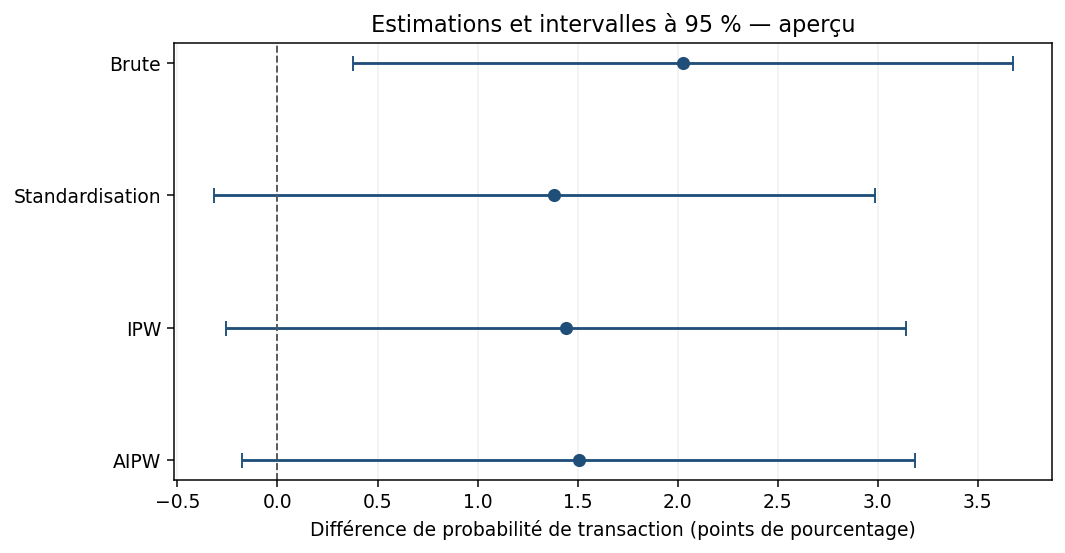

In [7]:
estimations = pd.read_csv(CHEMIN_ESTIMATIONS)
affichage_estimations = estimations.copy()
for colonne in ["Estimation (points)", "IC 95 % bas", "IC 95 % haut"]:
    affichage_estimations[colonne] = affichage_estimations[colonne].round(3)
display(affichage_estimations)

fig, ax = plt.subplots(figsize=(8, 4.2))
positions = np.arange(len(estimations))
centres = estimations["Estimation (points)"].to_numpy()
erreurs = np.vstack(
    [
        centres - estimations["IC 95 % bas"].to_numpy(),
        estimations["IC 95 % haut"].to_numpy() - centres,
    ]
)
ax.errorbar(centres, positions, xerr=erreurs, fmt="o", capsize=4, color="#1f4e79")
ax.axvline(0, color="#555555", linestyle="--", linewidth=1)
ax.set_yticks(positions, estimations["Méthode"])
ax.invert_yaxis()
ax.set_xlabel("Différence de probabilité de transaction (points de pourcentage)")
ax.set_title("Estimations et intervalles à 95 % — aperçu")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
tampon = io.BytesIO()
fig.savefig(tampon, format="png", dpi=135, bbox_inches="tight")
image_base64 = base64.b64encode(tampon.getvalue()).decode("ascii")
texte_alternatif = (
    "Graphique en points montrant les estimations brute, standardisée, IPW et AIPW "
    "avec leurs intervalles à 95 %. Les trois intervalles ajustés traversent zéro."
)
display(
    HTML(
        f'<figure><img src="data:image/png;base64,{image_base64}" alt="{texte_alternatif}" '
        'style="max-width:100%;height:auto">'
        '<figcaption>Aperçu des quatre estimations et de leurs intervalles à 95 %.</figcaption></figure>'
    )
)
plt.close(fig)


<div class="attention">

Le graphique précédent est seulement un **aperçu**. Nous n’avons pas encore appris pourquoi les méthodes ajustées diffèrent ni pourquoi l’AIPW a été choisie comme analyse principale. Ces questions seront traitées après les modules sur l’identification, le score de propension et les modèles de nuisance.

</div>


## Exercice 1A — Calculs et langage

<div class="exercice">

Répondre sans copier les formulations du cours.

1. Refaire manuellement les calculs `489 / 2 708` et `1 342 / 8 371`.
2. Expliquer la différence entre **+1,506 point** et **+1,506 % relatif**.
3. Traduire `+1,506 point` en nombre de transactions pour 1 000 sessions comparables.
4. Traduire l’intervalle `[−0,176 ; 3,188]` en nombre approximatif de transactions pour 1 000 sessions.
5. Pourquoi l’intervalle brut excluant zéro ne suffit-il pas à prouver un effet causal ?
6. Dans l’exemple fictif des promotions, comment obtient-on un écart global de 8 points alors que le weekend n’a aucun effet à promotion identique ?

</div>


### ✍️ Mes réponses à l’exercice 1A

**1. Mes calculs :**  
_À remplir_

**2. Point de pourcentage contre pourcentage relatif :**  
_À remplir_

**3. Traduction pour 1 000 sessions :**  
_À remplir_

**4. Traduction de l’intervalle :**  
_À remplir_

**5. Significativité brute contre causalité :**  
_À remplir_

**6. Exemple des promotions :**  
_À remplir_


## Exercice 1B — Corriger des affirmations de jury

Pour chaque affirmation, indiquer précisément ce qui est incorrect, puis proposer une meilleure formulation.

1. « Vous avez prouvé que le weekend augmente les achats de 2,03 %. »
2. « Comme l’intervalle AIPW contient zéro, votre étude prouve qu’il n’y a aucun effet. »
3. « L’association brute est statistiquement significative, donc les variables de confusion ne posent plus de problème. »
4. « `Revenue` est le chiffre d’affaires généré par chaque client. »


### ✍️ Mes corrections — exercice 1B

**Affirmation 1 :**  
_À remplir_

**Affirmation 2 :**  
_À remplir_

**Affirmation 3 :**  
_À remplir_

**Affirmation 4 :**  
_À remplir_


## Exercice oral 1C — Deux niveaux de réponse

### Question du jury

> « Le taux est plus élevé le weekend. Pourquoi ne concluez-vous pas directement que le weekend augmente les transactions ? »

Préparer deux réponses :

- une réponse de **20 secondes**, sans jargon inutile ;
- une réponse de **60 secondes**, structurée en D–A–C–L.

### ✍️ Ma réponse de 20 secondes

_À remplir, puis dire à voix haute sans lire._

### ✍️ Ma réponse de 60 secondes

- **Définition simple :** _À remplir_
- **Application au projet :** _À remplir_
- **Chiffre concret :** _À remplir_
- **Limite :** _À remplir_

**Durée réelle :** _À remplir_  
**Question de relance que je redoute :** _À remplir_


<details>
<summary><strong>Ouvrir seulement après avoir formulé une première réponse orale</strong></summary>

Une réponse possible de 20 secondes serait :

> « Nous observons 18,06 % de transactions le weekend contre 16,03 % en semaine, soit +2,03 points. Mais les groupes n’ont pas été randomisés et peuvent différer par leur composition ou par des causes non mesurées. Cette différence est donc descriptive ; une interprétation causale exige un ajustement et des hypothèses supplémentaires. »

Cette réponse est bonne parce qu’elle contient un résultat, le problème méthodologique et la limite, sans prétendre que l’ajustement réglera nécessairement tout.

</details>


## Point de passage du module 1

Je peux passer au module 2 lorsque je suis capable de :

- [ ] recalculer les deux taux observés sans regarder le rapport ;
- [ ] distinguer point de pourcentage et variation relative ;
- [ ] traduire une différence de risque en transactions pour 1 000 sessions ;
- [ ] expliquer pourquoi « statistiquement différent de zéro » ne signifie pas « causal » ;
- [ ] expliquer pourquoi un intervalle contenant zéro ne prouve pas un effet exactement nul ;
- [ ] répondre en 20 secondes à la question orale 1C ;
- [ ] citer au moins deux causes non mesurées plausibles sans affirmer qu’elles existent avec certitude.

**Niveau actuel estimé :** _/4_

<div class="oral">

**Formule de sécurité à l’oral :**  
« Le point estimé est positif, mais son interprétation dépend de la population, de l’échelle, de l’incertitude et des hypothèses causales. »

</div>


## Glossaire vivant — version actuelle

| Terme | Définition à ce stade |
|---|---|
| Unité d’analyse | Élément représenté par une observation : ici, une session de navigation. |
| Exposition | Variable dont on cherche à comprendre le contraste causal : ici, `Weekend`. |
| Résultat | Variable que l’exposition pourrait modifier : ici, `Revenue`, indicateur de transaction. |
| Proportion | Nombre de succès divisé par le nombre total d’observations. |
| Point de pourcentage | Différence absolue entre deux proportions exprimées en pourcentage. |
| Variation relative | Différence divisée par la valeur de référence. |
| Association | Différence ou relation observée entre des groupes. |
| Causalité | Changement du résultat qui surviendrait si l’on modifiait l’exposition dans une comparaison hypothétique bien définie. |
| Intervalle de confiance | Intervalle construit par une procédure destinée à quantifier l’incertitude d’échantillonnage. |
| Confusion | Mélange entre le contraste d’intérêt et l’effet de différences de composition ou de causes communes. |

Ce glossaire sera enrichi et parfois précisé. Une définition de début de parcours peut être correcte sans être encore complète.


## Journal de questions

Noter ici toute question, même si elle semble élémentaire. Une hésitation clairement formulée est un outil d’apprentissage.

| Question | Ma réponse actuelle | Ce qui reste flou | Réponse consolidée plus tard |
|---|---|---|---|
| _À remplir_ | _À remplir_ | _À remplir_ | |


# Arrêt pédagogique — ne pas ajouter de nouveau module avant la récupération active

1. Exécuter les cellules du notebook dans l’ordre.
2. Remplir le diagnostic initial sans effacer les réponses spontanées.
3. Compléter les exercices 0A, 1A, 1B et 1C.
4. Dire les réponses orales réellement à voix haute.
5. Faire corriger les réponses avant de développer le module 2.

Le prochain bloc portera sur :

- les résultats potentiels \(Y(1)\) et \(Y(0)\) ;
- le problème fondamental de l’inférence causale ;
- l’intervention hypothétique correspondant à `Weekend` ;
- la population cible et l’estimand ;
- la différence entre ATE, ATT, CATE et effet individuel.

<!-- ANCRE_PROCHAIN_MODULE -->
